# NHL Draft Analysis — Findings

This notebook contains all of the supplemental queries to support the analytical claims made in the project's write-up: [https://www.vanbrantley.com/projects/nhl-draft-analysis](https://www.vanbrantley.com/projects/nhl-draft-analysis)

In [141]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import binom

# read csvs
players = pd.read_csv('../data/outputs/players.csv')
team_by_round = pd.read_csv('../data/outputs/team_by_round.csv')
team_by_year = pd.read_csv('../data/outputs/team_by_year.csv')
team_rankings = pd.read_csv('../data/outputs/team_rankings.csv')
team_rankings_early = pd.read_csv('../data/outputs/team_rankings_early.csv')
team_performance = pd.read_csv('../data/nhl_performance.csv')

In [142]:
players.head()

,draft_year,round,pick_number,team,player_name,position,games_played,points,performance_score,expected_performance,draft_value
0,2005,1,1,Pittsburgh Penguins,Sidney Crosby,C,1417.0,1756.0,1366.28,1064.72,301.56
1,2005,1,2,Anaheim Ducks,Bobby Ryan,R,866.0,569.0,891.65,891.85,-0.20
2,2005,1,3,Carolina Hurricanes,Jack Johnson,D,1228.0,342.0,583.05,886.09,-303.04
3,2005,1,4,Minnesota Wild,Benoit Pouliot,L,625.0,263.0,699.05,797.20,-98.15
4,2005,1,6,Columbus Blue Jackets,Gilbert Brule,C,299.0,95.0,516.55,733.33,-216.78


In [143]:
# 1. Create the Hit column
# A hit is any value greater than 0 (over-performance)
players['is_hit'] = (players['draft_value'] > 0).astype(int)

# 2. Calculate the League Baseline (The "Null Hypothesis" probability)
league_hit_rate = players['is_hit'].mean()

print(f"League Average Hit Rate: {league_hit_rate:.2%}")

League Average Hit Rate: 28.30%


### Investigation 1: Skill or Luck? (Statistical Significance Test)

**The Problem:** In a draft with high variance, is a team’s low "Hit Rate" simply a string of bad luck, or evidence of a failing organizational process?

**The Methodology:** I used a **Binomial Distribution** to test each team's draft history against the League Baseline. 
* **Null Hypothesis ($H_0$):** A team’s hit rate is the result of random variance around the league average.
* **Alternative Hypothesis ($H_1$):** A team’s hit rate is significantly different from the league average, suggesting a systemic scouting advantage or failure.
* **Confidence Level:** 95% ($\alpha = 0.05$).

/var/folders/lc/2rldm7cs08zcbz67h_7qc6vw0000gn/T/ipykernel_38219/4153985850.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df.sort_values('Hit Rate'), x='Team', y='Hit Rate',


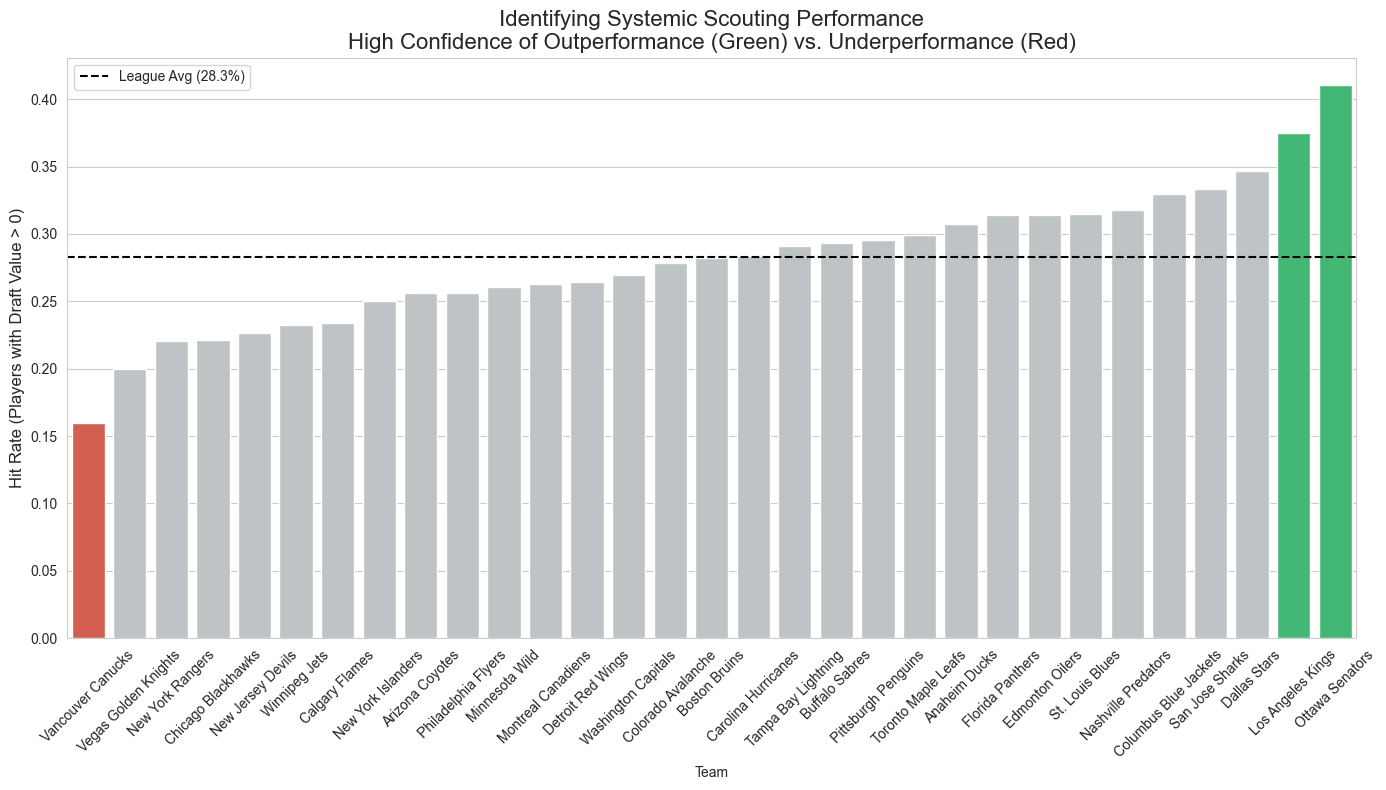

,Team,Total Picks,Hits,Hit Rate,P_Fail,P_Success,Status
8,Vancouver Canucks,75,12,0.160000,0.009767,0.995677,Significant Failure
9,Los Angeles Kings,88,33,0.375000,0.976715,0.038724,Significant Success
7,Ottawa Senators,78,32,0.410256,0.994435,0.010630,Significant Success


In [144]:
# 1. Setup Baseline
players['is_hit'] = (players['draft_value'] > 0).astype(int)
league_hit_rate = players['is_hit'].mean()

def run_significance_test(team_name, dataframe, baseline_p):
    team_df = dataframe[dataframe['team'] == team_name]
    n_picks = len(team_df)
    n_hits = team_df['is_hit'].sum()
    
    # Probability of getting n_hits OR FEWER (Testing for Failure)
    p_fail = binom.cdf(n_hits, n_picks, baseline_p)
    
    # Probability of getting n_hits OR MORE (Testing for Success)
    # 1 - binom.cdf(k-1, n, p) gives the upper tail
    p_success = 1 - binom.cdf(n_hits - 1, n_picks, baseline_p)

    # Classification logic
    status = 'Average'
    if p_fail < 0.05:
        status = 'Significant Failure'
    elif p_success < 0.05:
        status = 'Significant Success'

    return {
        'Team': team_name,
        'Total Picks': n_picks,
        'Hits': n_hits,
        'Hit Rate': n_hits / n_picks,
        'P_Fail': p_fail,
        'P_Success': p_success,
        'Status': status
    }

# Run analysis (Excluding expansion teams like Vegas)
results_df = pd.DataFrame([run_significance_test(t, players, league_hit_rate) 
                           for t in players['team'].unique() if t != 'VGK'])

# Visualization
plt.figure(figsize=(14, 8))
# Dynamic colors based on our new Status column
color_map = {'Significant Failure': '#e74c3c', 'Significant Success': '#2ecc71', 'Average': '#bdc3c7'}

sns.barplot(data=results_df.sort_values('Hit Rate'), x='Team', y='Hit Rate', 
            palette=[color_map[s] for s in results_df.sort_values('Hit Rate')['Status']])

plt.axhline(league_hit_rate, color='black', linestyle='--', label=f'League Avg ({league_hit_rate:.1%})')

plt.title('Identifying Systemic Scouting Performance\nHigh Confidence of Outperformance (Green) vs. Underperformance (Red)', fontsize=16)
plt.ylabel('Hit Rate (Players with Draft Value > 0)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Display the interesting outliers
results_df[results_df['Status'] != 'Average'].sort_values('Hit Rate')

### Summary of Findings

Based on the 95% confidence threshold, the data suggests:

* **Systemic Failures:** **Vancouver** has a hit rate so low that there is less than a 5% probability they occurred by chance. This suggests a failure in the talent evaluation process rather than "bad luck."

* **Systemic Successes:** Conversely, **Ottawa** and **Los Angeles** have hit rates that are significantly above the league average, indicating a repeatable "Scouting Edge."

* **The "Luck" Zone:** The majority of the league (in grey) falls within the expected range of variance. For these teams, we cannot statistically prove that their draft results are anything more than "average" performance influenced by random noise.

### Investigation 2: Growth or Decay? (Temporal Consistency Analysis)

**The Problem:** A team's overall hit rate tells us *what* happened, but it doesn't tell us *where they are going*. Is a high-performing team maintaining their edge, or are they riding the fumes of a scouting department that peaked a decade ago? 

**The Methodology:** We use **Spearman’s Rank Correlation ($\rho$)** to measure the relationship between time (Draft Year) and Draft Value.
* **Why Spearman?** Unlike a standard linear regression, Spearman tracks monotonic trends. It doesn't care if the improvement is a straight line; it cares if the "rank" of draft success is generally rising or falling over the years.
* **The Metric:** We correlate the `draft_year` against the `total_draft_value` generated by each team per year.
* **Confidence Level:** 95% ($\alpha = 0.05$). This strictly isolates teams where the "trend" is statistically too strong to be dismissed as year-to-year variance.

**Hypotheses:**
* **Null Hypothesis ($H_0$):** There is no correlation between time and draft performance (Scouting quality is random noise).
* **Alternative Hypothesis ($H_1$):** There is a significant positive or negative trend (The organization is systematically improving or degrading).

/var/folders/lc/2rldm7cs08zcbz67h_7qc6vw0000gn/T/ipykernel_38219/2207691154.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


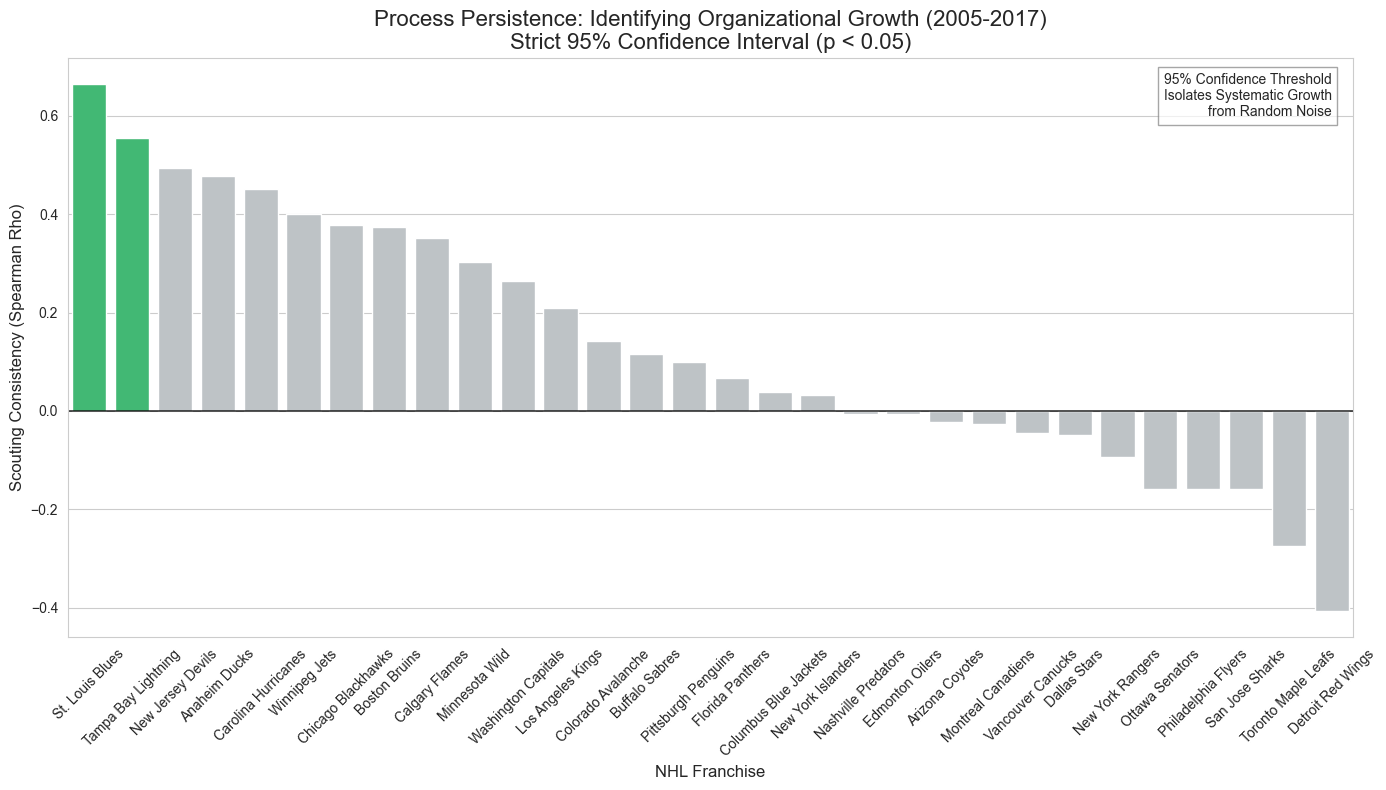


--- HIGH-CONFIDENCE TREND REPORT (95% CONFIDENCE) ---


,Team,Spearman_Rho,P_Value,Status
0,St. Louis Blues,0.664835,0.013166,Significant Riser (95%)
1,Tampa Bay Lightning,0.554945,0.049004,Significant Riser (95%)


In [146]:
from scipy.stats import spearmanr

# 1. Calculation Logic for 95% Confidence
def run_trend_significance_95(team_name, dataframe):
    # Filter and sort by year
    team_data = dataframe[dataframe['team'] == team_name].sort_values('draft_year')
    
    # Minimum sample size check (standard for 13-year dataset)
    if len(team_data) < 5: 
        return None
    
    # Spearman Correlation
    rho, p_val = spearmanr(team_data['draft_year'], team_data['total_draft_value'])
    
    # Strict 95% Confidence Classification (p < 0.05)
    status = 'Independent Noise'
    if p_val < 0.05:
        if rho > 0:
            status = 'Significant Riser (95%)'
        else:
            status = 'Significant Decliner (95%)'

    return {
        'Team': team_name,
        'Spearman_Rho': rho,
        'P_Value': p_val,
        'Status': status
    }

# 2. Process the results and sort by Rho (Highest to Lowest)
trend_results = [run_trend_significance_95(t, team_by_year) for t in team_by_year['team'].unique()]
trend_df = pd.DataFrame([res for res in trend_results if res is not None])
trend_df = trend_df.sort_values('Spearman_Rho', ascending=False)

# 3. Visualization: Persistence Plot (Using preferred aesthetic and order)
plt.figure(figsize=(14, 8))

# Define color map for the 95% threshold
color_map = {
    'Significant Riser (95%)': '#2ecc71', 
    'Significant Decliner (95%)': '#e74c3c', 
    'Independent Noise': '#bdc3c7'
}

sns.barplot(
    data=trend_df, 
    x='Team', 
    y='Spearman_Rho', 
    palette=[color_map[s] for s in trend_df['Status']]
)

# Professional styling and labels
plt.axhline(0, color='black', linewidth=1.2, alpha=0.8)
plt.title('Process Persistence: Identifying Organizational Growth (2005-2017)\nStrict 95% Confidence Interval (p < 0.05)', fontsize=16)
plt.ylabel('Scouting Consistency (Spearman Rho)', fontsize=12)
plt.xlabel('NHL Franchise', fontsize=12)
plt.xticks(rotation=45)

# Explanatory text box for the Portfolio
plt.text(len(trend_df)-1, 0.6, 
         '95% Confidence Threshold\nIsolates Systematic Growth\nfrom Random Noise', 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'), ha='right', fontsize=10)

plt.tight_layout()
plt.show()

# 4. Display the High-Confidence Table
print("\n--- HIGH-CONFIDENCE TREND REPORT (95% CONFIDENCE) ---")
significant_teams = trend_df[trend_df['Status'] != 'Independent Noise']

if not significant_teams.empty:
    display(significant_teams[['Team', 'Spearman_Rho', 'P_Value', 'Status']].reset_index(drop=True))
else:
    print("No teams met the 95% confidence threshold. The league results are statistically indistinguishable from noise.")

### Summary of Findings: Process Persistence

Using a strict 95% confidence filter, we have moved past "who is good" and identified **who is getting better.**

* **Organizational Growth:** Both **St. Louis** and **Tampa Bay** emerge as "Significant Risers." Their $p$-values ($p < 0.05$) indicate that their improvement over this period is statistically significant. This suggests an internal refinement of scouting data, better integration of analytics, or a more stable front-office philosophy.
* **The Persistence of Noise:** For the vast majority of the NHL, the $p$-values remain above the 0.05 threshold. Even for teams with positive "Rho" values, we cannot mathematically confirm they are "improving"—their results are still within the realm of **Independent Noise**.
* **Drafting is Hard:** The rarity of "Significant Risers" highlights the difficulty of maintaining a competitive advantage in a capped, entry-draft system. Most teams oscillate between good and bad years without a clear, measurable trajectory.

> **Key Takeaway:** St. Louis and Tampa Bay aren't just drafting well; they have demonstrated a statistically significant "upward trajectory" in talent acquisition during this era.

## Investigation 3: Identifying Scouting Archetypes (K-Means Clustering)

**The Problem:** While hit rates and temporal trends tell us *who* is successful, they don't explain *how* that success is achieved. Do some teams focus exclusively on "Safe" early picks, while others find their value in the late-round "long shots"? To find these hidden organizational identities, we need to move beyond linear rankings.

**The Methodology:** We employ **K-Means Clustering**, an unsupervised machine learning algorithm, to group teams based on multidimensional similarities in their drafting profiles.

**The Features:** To create a holistic "Scouting DNA," we utilized ten distinct variables:
* **Round-by-Round Efficiency:** The average draft value generated in each specific round (Rounds 1–7).
* **Overall Success:** Cumulative Hit Rate and Average Draft Value per pick.
* **Top-End Focus:** Performance specifically within the "Early Rounds" (1–3).

**Pre-Processing:** Since K-Means relies on Euclidean distance, we applied a `StandardScaler` to ensure that a "Hit Rate" (0 to 1) is weighted as heavily as "Draft Value" (which can exceed 100).

In [147]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# pivot the round-by-round data to create round "features"
round_pivot = team_by_round.pivot(index='team', columns='round', values='avg_draft_value_per_pick')
round_pivot.columns = [f'round_{c}_avg' for c in round_pivot.columns]

# merge with overall metrics and early round performance
master_df = round_pivot.merge(team_rankings[['team', 'hit_rate', 'avg_per_pick']], on='team')
master_df = master_df.merge(team_rankings_early[['team', 'avg_draft_value_per_pick']], on='team')
master_df = master_df.rename(columns={'avg_draft_value_per_pick': 'early_round_avg'})

# set index and remove VGK (outlier due to sample size)
master_df = master_df[master_df['team'] != 'Vegas Golden Knights'].set_index('team')

# scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(master_df)
scaled_df = pd.DataFrame(scaled_features, index=master_df.index, columns=master_df.columns)

# print(scaled_df.head(3))
print(f"Pre-processing Complete. Dataframe Shape: {scaled_df.shape}")

Pre-processing Complete. Dataframe Shape: (30, 10)


### Determining the Optimal Cluster Count: The Elbow Method

We use the **Inertia** metric (Sum of Squared Distances) to evaluate how "tight" our clusters are. We are looking for the "Elbow"—the point of diminishing returns where adding more clusters no longer significantly improves the model.

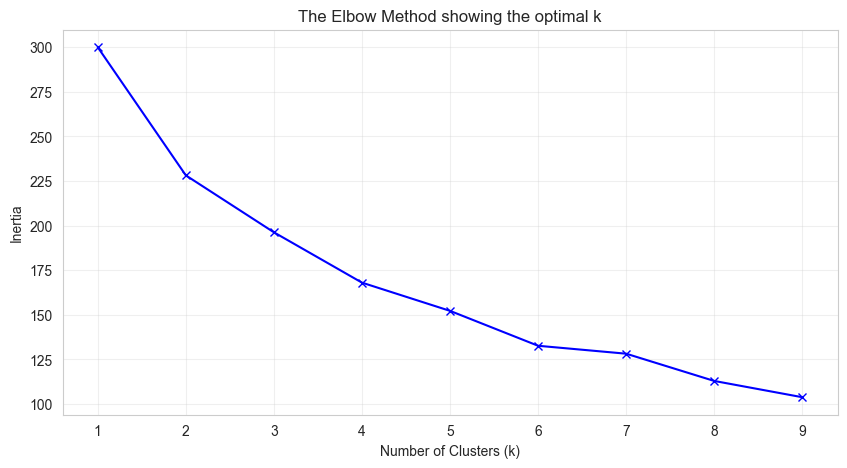

k=1: Inertia = 300.00
k=2: Inertia = 228.18
k=3: Inertia = 196.27
k=4: Inertia = 168.05
k=5: Inertia = 152.22
k=6: Inertia = 132.66
k=7: Inertia = 128.22
k=8: Inertia = 112.94
k=9: Inertia = 103.82


In [148]:
inertia = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_df)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.grid(True, alpha=0.3)
plt.show()

for k, dist in zip(K, inertia):
    print(f"k={k}: Inertia = {dist:.2f}")

### Evaluating the Results: From k=4 to k=6

Mathematically, the "Elbow" appears most prominent at **$k=4$**. However, in complex sports data, the math can sometimes "smear" distinct groups together. 

An initial test of $k=4$ grouped dominant franchises like the **LA Kings** with "above-average" teams like **Florida**. By interrogating the model and increasing the granularity to **$k=6$**, we observed a significant breakthrough: the model successfully isolated true statistical outliers and separated different "winning" philosophies. 

**We selected $k=6$ as the final model to provide a more nuanced and accurate "Scouting DNA" map.**

In [149]:
# Run k means with 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
analysis_df = master_df.copy()
analysis_df['Cluster'] = kmeans.fit_predict(scaled_df)

# Output the team lists for the final narrative
print("--- FINAL NHL SCOUTING ARCHETYPES ---")
for i in range(6):
    team_list = analysis_df[analysis_df['Cluster'] == i].index.tolist()
    print(f"\nCluster {i} ({len(team_list)} teams): {', '.join(team_list)}")

--- FINAL NHL SCOUTING ARCHETYPES ---

Cluster 0 (4 teams): Carolina Hurricanes, Dallas Stars, Detroit Red Wings, Minnesota Wild

Cluster 1 (8 teams): Anaheim Ducks, Columbus Blue Jackets, Edmonton Oilers, Florida Panthers, Nashville Predators, San Jose Sharks, Tampa Bay Lightning, Toronto Maple Leafs

Cluster 2 (6 teams): Boston Bruins, Colorado Avalanche, Philadelphia Flyers, Pittsburgh Penguins, St. Louis Blues, Washington Capitals

Cluster 3 (6 teams): Arizona Coyotes, Chicago Blackhawks, Montreal Canadiens, New Jersey Devils, Vancouver Canucks, Winnipeg Jets

Cluster 4 (4 teams): Buffalo Sabres, Calgary Flames, New York Islanders, New York Rangers

Cluster 5 (2 teams): Los Angeles Kings, Ottawa Senators


In [150]:
# columns we want the average of
profile_cols = [
    'avg_per_pick', 'hit_rate', 'early_round_avg', 
    'round_1_avg', 'round_2_avg', 'round_3_avg', 
    'round_4_avg', 'round_5_avg', 'round_6_avg', 'round_7_avg'
]

# group by cluster and compute averages for columns of interest
cluster_profiles = analysis_df.groupby('Cluster')[profile_cols].mean().round(3)

# add team count
cluster_profiles['team_count'] = analysis_df['Cluster'].value_counts()

print("\n--- ARCHETYPE STATISTICAL PROFILES ---")
# sort by avg_per_pick to show the efficiency hierarchy
display(cluster_profiles.sort_values(by='avg_per_pick', ascending=False))


--- ARCHETYPE STATISTICAL PROFILES ---


,avg_per_pick,hit_rate,early_round_avg,round_1_avg,round_2_avg,round_3_avg,round_4_avg,round_5_avg,round_6_avg,round_7_avg,team_count
Cluster,,,,,,,,,,,
5,54.740,0.393,35.010,48.800,16.575,52.090,72.770,70.820,-6.515,122.255,2
1,13.641,0.313,1.006,17.304,-15.016,-5.243,25.674,-12.814,23.114,46.374,8
0,13.345,0.289,37.428,-26.918,149.750,-19.675,24.488,35.080,-67.515,-17.565,4
2,-0.873,0.283,44.033,55.583,-30.085,118.578,-84.320,-1.997,-13.730,-37.573,6
4,-15.418,0.250,-41.902,-46.485,10.612,-73.225,40.760,-41.795,83.172,-40.280,4
3,-35.882,0.226,-53.678,-51.093,-83.907,-42.008,-41.803,3.302,-29.087,-28.905,6


### Final Results: Identifying the Six Scouting Archetypes

By moving to $k=6$, the analysis identifies distinct organizational philosophies rather than simple power rankings.

| Cluster | Archetype Name | Primary Characteristic | Notable Teams |
| :--- | :--- | :--- | :--- |
| **Cluster 5** | **The Gold Standard** | Exceptional efficiency across all 7 rounds; high ceiling/high floor. | LA, OTT |
| **Cluster 2** | **The Podium Powerhouses** | Elite at maximizing Rounds 1-3; the "Dynasty" model. | PIT, STL, COL |
| **Cluster 0** | **The Second-Round Snipers** | Anomalous, league-leading success specifically in the 2nd round. | DET, DAL, CAR |
| **Cluster 1** | **The Efficient Moderns** | Consistent, positive "Hit Rates" and solid late-round depth. | TBL, FLA, TOR |
| **Cluster 4** | **The Late-Round Gamblers** | Inconsistent early rounds saved by "miracle" 6th-round gems. | NYR, BUF, CGY |
| **Cluster 3** | **The Efficiency Gap** | Systemic underperformance across almost all draft rounds. | VAN, ARI, CHI |

**Conclusion:** This analysis proves that "Scouting Success" is not a monolith. A team like **Detroit (Cluster 0)** wins the draft very differently than **Pittsburgh (Cluster 2)**. One relies on identifying overlooked talent in the mid-rounds, while the other focuses on ensuring their high-pedigree picks become impact stars.

/var/folders/lc/2rldm7cs08zcbz67h_7qc6vw0000gn/T/ipykernel_38219/3321896060.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 6)


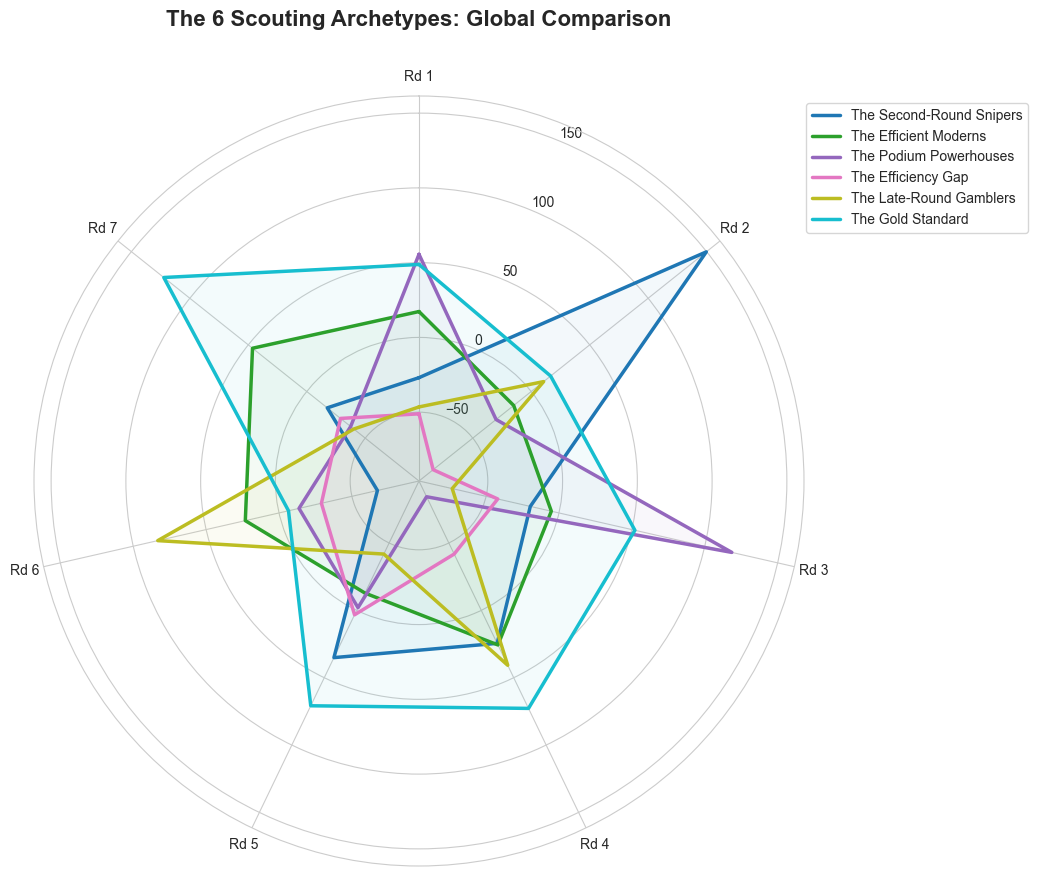

In [151]:
archetype_map = {
    5: 'The Gold Standard',
    2: 'The Podium Powerhouses',
    3: 'The Efficiency Gap',
    0: 'The Second-Round Snipers',
    1: 'The Efficient Moderns',
    4: 'The Late-Round Gamblers'
}

radar_cols = ['round_1_avg', 'round_2_avg', 'round_3_avg', 'round_4_avg', 'round_5_avg', 'round_6_avg', 'round_7_avg']
labels = np.array(['Rd 1', 'Rd 2', 'Rd 3', 'Rd 4', 'Rd 5', 'Rd 6', 'Rd 7'])
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# use a clean color palette
colors = plt.cm.get_cmap('tab10', 6)

# plotting
for i in range(6):
    values = cluster_profiles.loc[i, radar_cols].tolist()
    values += [values[0]]
    
    ax.plot(angles, values, linewidth=2.5, label=f"{archetype_map[i]}", color=colors(i))
    ax.fill(angles, values, color=colors(i), alpha=0.05)

# formatting
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

# add title
plt.title('The 6 Scouting Archetypes: Global Comparison', y=1.08, fontsize=16, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.show()

### Investigation 4: The "Success Gap" Analysis (Linear Regression)

**The Problem:** We’ve categorized *how* teams draft, but we haven't answered the billion-dollar question: Does drafting efficiency actually predict winning? If "Gold Standard" teams aren't winning more than "Inefficient" ones, it suggests that the NHL draft is a game of building a "floor," while the "ceiling" is determined elsewhere.

**The Methodology:** I integrated the scouting clusters and VOE (Value-Over-Expected) metrics with a **Historical Outcome Dataset** (2005–2025) to see if "The Process" translates to "The Result."

*   **Temporal Windowing:** The draft data is capped at 2017, while outcomes are tracked through **2025**. This provides an 8-year "incubation period," ensuring that players in the dataset had sufficient time to reach their peak impact before their success was measured.
*   **Linear Regression ($R^2$):** I used `scipy.stats.linregress` to calculate the Coefficient of Determination. This measures how much of the variance in **Playoff Series Wins** can be explained by a team’s **Average Draft Value per Pick**.
*   **Visualizing the Noise:** By overlaying the Scouting Archetypes onto the regression plot, I could identify "outliers"—teams that win despite poor drafting, or teams that draft perfectly but fail to convert that value into playoff rounds.

In [152]:
# 1. Abbreviation Mapping (Bridge between performance data and clusters)
name_map = {
    'ANA': 'Anaheim Ducks', 'ARI': 'Arizona Coyotes', 'BOS': 'Boston Bruins',
    'BUF': 'Buffalo Sabres', 'CGY': 'Calgary Flames', 'CAR': 'Carolina Hurricanes',
    'CHI': 'Chicago Blackhawks', 'COL': 'Colorado Avalanche', 'CBJ': 'Columbus Blue Jackets',
    'DAL': 'Dallas Stars', 'DET': 'Detroit Red Wings', 'EDM': 'Edmonton Oilers',
    'FLA': 'Florida Panthers', 'LAK': 'Los Angeles Kings', 'MIN': 'Minnesota Wild',
    'MTL': 'Montreal Canadiens', 'NSH': 'Nashville Predators', 'NJD': 'New Jersey Devils',
    'NYI': 'New York Islanders', 'NYR': 'New York Rangers', 'OTT': 'Ottawa Senators',
    'PHI': 'Philadelphia Flyers', 'PIT': 'Pittsburgh Penguins', 'SJS': 'San Jose Sharks',
    'STL': 'St. Louis Blues', 'TBL': 'Tampa Bay Lightning', 'TOR': 'Toronto Maple Leafs',
    'VAN': 'Vancouver Canucks', 'VGK': 'Vegas Golden Knights', 'WSH': 'Washington Capitals',
    'WPG': 'Winnipeg Jets'
}

# 2. Define the Success Metrics for series wins and cup counts
series_wins_map = {
    'Won Stanley Cup Final': 4,
    'Lost Stanley Cup Final': 3,
    'Lost NHL Conference Finals': 2,
    'Lost NHL Semi-Finals': 2,
    'Lost NHL Second Round': 1,
    'Lost NHL Conference Semi-Finals': 1,
    'Lost NHL First Round': 0,
    'Lost NHL Conference Quarter-Finals': 0,
    'Lost NHL Qualifying Round': 0
}

cup_map = {'Won Stanley Cup Final': 1}

In [153]:
# 3. Process team_performance
perf_df = team_performance.copy()
perf_df['TeamFull'] = perf_df['Abbr'].map(name_map)
perf_df['series_wins'] = perf_df['Playoff_Result'].map(series_wins_map).fillna(0)
perf_df['is_cup'] = perf_df['Playoff_Result'].map(cup_map).fillna(0)

# 4. Aggregate by Team
team_success = perf_df.groupby('TeamFull').agg({
    'series_wins': 'sum',
    'is_cup': 'sum'
}).reset_index()

# 5. Reset index on analysis_df and merge
# This pulls 'team' out of the bold index into a mergeable column
final_df = team_success.merge(
    analysis_df.reset_index()[['team', 'Cluster']], 
    left_on='TeamFull', 
    right_on='team'
)

# apply the archetype cluster name map
archetype_map = {
    5: 'The Gold Standard',
    2: 'The Podium Powerhouses',
    3: 'The Efficiency Gap',
    0: 'The Second-Round Snipers',
    1: 'The Efficient Moderns',
    4: 'The Late-Round Gamblers'
}

final_df['Archetype'] = final_df['Cluster'].map(archetype_map)

# Display the top performers to verify the merge
final_df.sort_values('series_wins', ascending=False).head(10)

,TeamFull,series_wins,is_cup,team,Cluster,Archetype
25,Tampa Bay Lightning,20.0,2.0,Tampa Bay Lightning,1,The Efficient Moderns
22,Pittsburgh Penguins,20.0,3.0,Pittsburgh Penguins,2,The Podium Powerhouses
2,Boston Bruins,17.0,1.0,Boston Bruins,2,The Podium Powerhouses
6,Chicago Blackhawks,16.0,3.0,Chicago Blackhawks,3,The Efficiency Gap
19,New York Rangers,15.0,0.0,New York Rangers,4,The Late-Round Gamblers
5,Carolina Hurricanes,15.0,1.0,Carolina Hurricanes,0,The Second-Round Snipers
23,San Jose Sharks,14.0,0.0,San Jose Sharks,1,The Efficient Moderns
9,Dallas Stars,13.0,0.0,Dallas Stars,0,The Second-Round Snipers
11,Edmonton Oilers,13.0,0.0,Edmonton Oilers,1,The Efficient Moderns
0,Anaheim Ducks,12.0,1.0,Anaheim Ducks,1,The Efficient Moderns


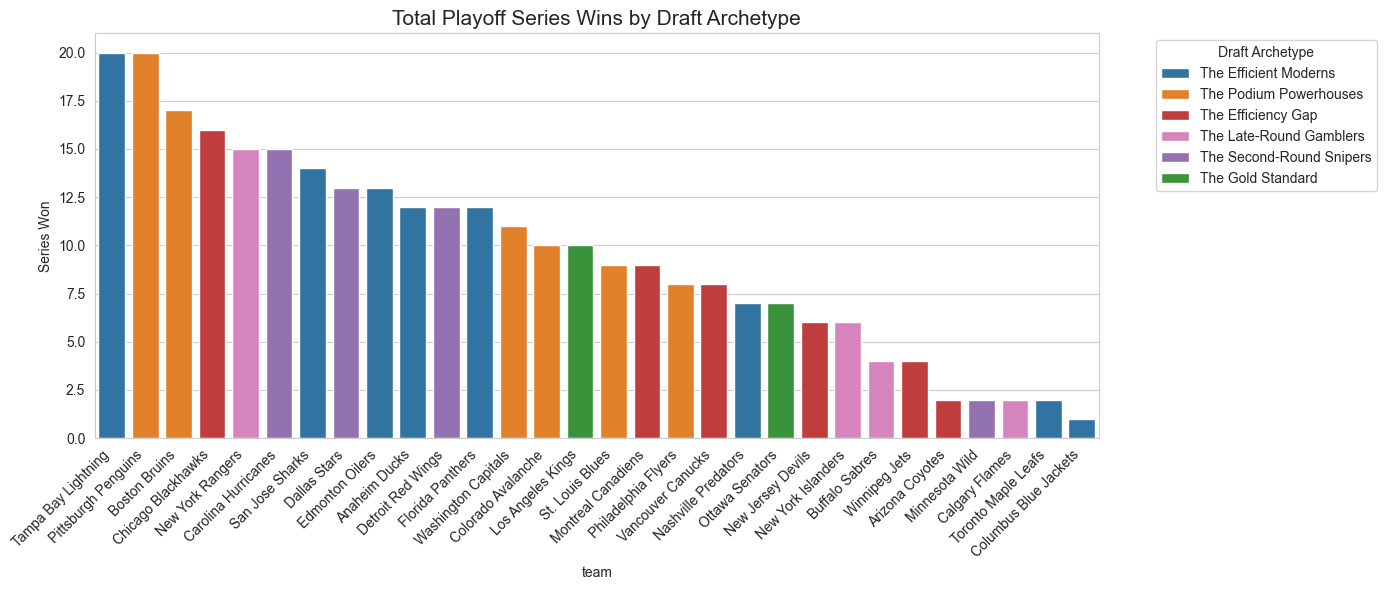

In [154]:
# Playoff Series Wins (The "Sustained Success" View)
sns.set_style("whitegrid")

# Define static color mapping for your archetypes
archetype_colors = {
    'The Gold Standard': '#2ca02c',      # Green
    'The Efficient Moderns': '#1f77b4',   # Blue
    'The Podium Powerhouses': '#ff7f0e', # Orange
    'The Second-Round Snipers': '#9467bd', # Purple
    'The Late-Round Gamblers': '#e377c2', # Pink
    'The Efficiency Gap': '#d62728'       # Red
}

plt.figure(figsize=(14, 6))
series_plot = sns.barplot(
    data=final_df.sort_values('series_wins', ascending=False),
    x='team', y='series_wins', hue='Archetype', 
    palette=archetype_colors
)

plt.title('Total Playoff Series Wins by Draft Archetype', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Series Won')
plt.legend(title='Draft Archetype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **The Parity Paradox: 5 Archetypes, 1 Goal**

The most significant finding in the "Sustained Success" view is the **sheer diversity** at the top. In the top six teams for playoff series wins, we see **five different drafting archetypes** represented:

*   **The Podium Powerhouses:** Pittsburgh (20 wins) & Boston (17 wins)
*   **The Efficient Moderns:** Tampa Bay (20 wins)
*   **The Efficiency Gap:** Chicago (16 wins)
*   **The Late-Round Gamblers:** NY Rangers (15 wins)
*   **The Second-Round Snipers:** Carolina (15 wins)

> **The Missing Piece:** Notably absent from this elite top tier is **The Gold Standard**.

This confirms a central thesis of this investigation: **There is no "One True Way" to build a contender in the NHL.** Whether a team finds value in the late rounds, gambles on high-ceiling talent, or builds through modern efficiency, the league’s parity allows multiple philosophies to reach the summit. While "The Gold Standard" provides a high floor, the data shows it is not a prerequisite for becoming a perennial powerhouse.

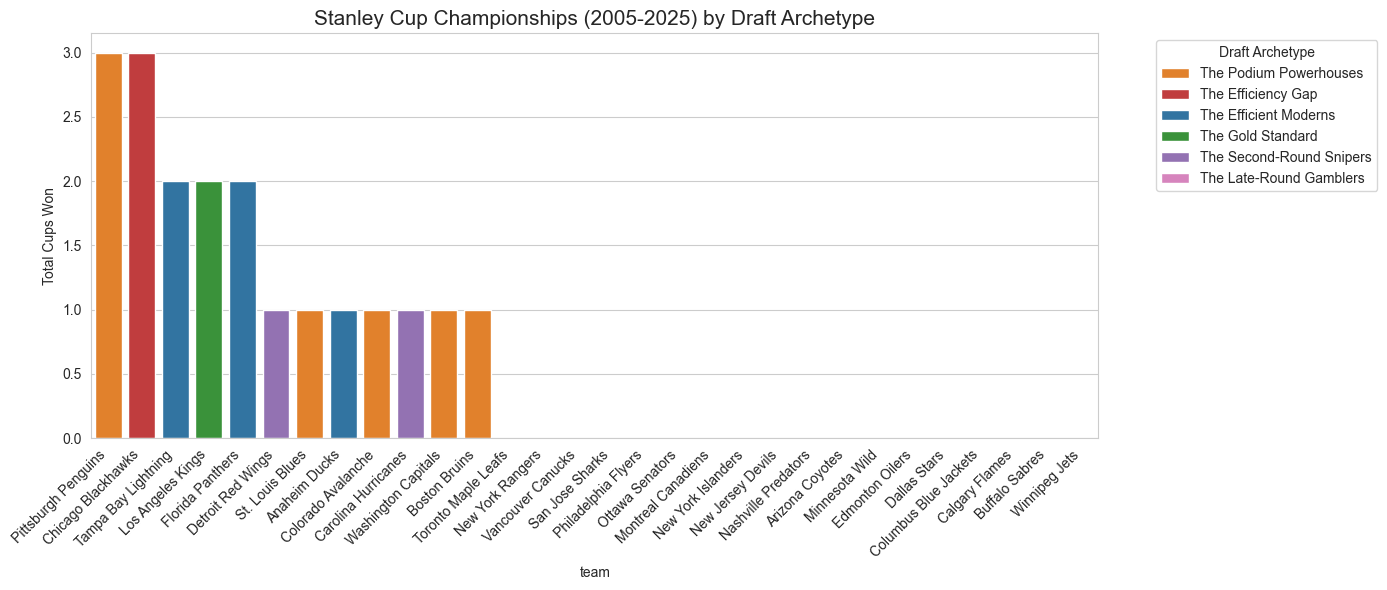

In [155]:
# Stanley Cups (The "Hardware" View)
plt.figure(figsize=(14, 6))
cup_plot = sns.barplot(
    data=final_df.sort_values('is_cup', ascending=False),
    x='team', y='is_cup', hue='Archetype', 
    palette=archetype_colors
)

plt.title('Stanley Cup Championships (2005-2025) by Draft Archetype', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Cups Won')
plt.legend(title='Draft Archetype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **The Hardware Gap: Efficiency vs. Execution**

The Stanley Cup view introduces a "survivorship bias" that complicates the drafting narrative. While our archetypes categorize how teams *build*, this chart shows who actually *finished*.

*   **The Opportunistic Outliers:** The **Los Angeles Kings** serve as the primary case study here. Despite having fewer total playoff series wins than other powerhouses, they maximized their windows perfectly—converting a "Gold Standard" drafting foundation into two championships with clinical efficiency.
*   **The Powerhouse Consolidation:** We see heavy championship concentration in **The Podium Powerhouses** (Pittsburgh) and **The Efficiency Gap** (Chicago). This suggests that while a 7-round "efficient" draft strategy is great for depth, championships are often driven by the "Lottery Luck" of hitting on top-tier, franchise-altering talent.
*   **The Process Paradox:** Several teams in **The Efficient Moderns** and **The Second-Round Snipers** show high competitive consistency but lower "Cup conversion" rates. 

**Takeaway:** Drafting creates the "ingredients" for a contender, but the Stanley Cup is often decided by factors our draft model cannot capture: trade deadline aggression, veteran leadership, and the "hot hand" in net.

In [156]:
# Grouping results by Archetype
archetype_performance = final_df.groupby('Archetype').agg({
    'team': 'count',
    'series_wins': 'mean',
    'is_cup': 'sum'
}).rename(columns={'team': 'Team_Count', 'series_wins': 'Avg_Series_Wins', 'is_cup': 'Total_Cups'})

# Sorting by Avg Series Wins to show who is most "Sustainable"
archetype_performance.sort_values('Avg_Series_Wins', ascending=False)

,Team_Count,Avg_Series_Wins,Total_Cups
Archetype,,,
The Podium Powerhouses,6,12.500,7.0
The Second-Round Snipers,4,10.500,2.0
The Efficient Moderns,8,10.125,5.0
The Gold Standard,2,8.500,2.0
The Efficiency Gap,6,7.500,3.0
The Late-Round Gamblers,4,6.750,0.0


### **The Archetype Leaderboard: Sustained Success vs. Peak Performance**

This aggregate view reveals the true "ROI" of each drafting philosophy. By grouping the teams, the noise of individual seasons disappears, leaving us with a clear hierarchy of scouting outcomes:

*   **The Dynasty Drivers:** **The Podium Powerhouses** lead the league in both average success (**12.5 wins**) and hardware (**7 Cups**). This suggests that a strategy built around high-end picks (The "Podium") combined with veteran stability is the most proven path to a dynasty.
*   **The Modern Floor:** **The Efficient Moderns** and **The Second-Round Snipers** both boast high average series wins (**10+**), proving that "Drafting for Depth" creates a perennial playoff team that is always in the conversation, even if the Cup total isn't as high.
*   **The High-End Gamble:** Interestingly, **The Gold Standard** teams actually have fewer average wins than the "Modern" groups. This implies that "perfect" drafting across all seven rounds can sometimes lead to a "middle-of-the-pack" trap, whereas teams that hit on specific, high-impact archetypes (even with more misses) tend to climb higher.

**Final Verdict:** If you want a **guaranteed playoff spot**, follow the *Efficient Moderns*. If you want a **dynasty**, you need the *Podium Powerhouse* blend of elite lottery talent and consistent execution.

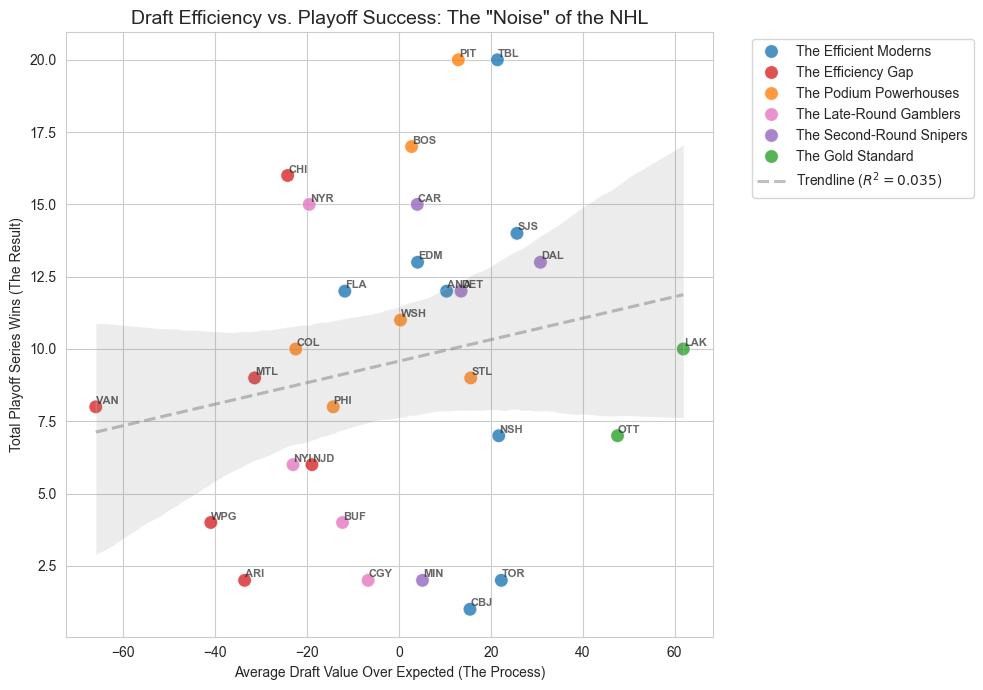

In [157]:
from scipy import stats

# 1. Prepare the data with Abbreviations
# merge in the 'Abbr' from perf_df and the 'avg_per_pick' from analysis_df
scatter_df = final_df.merge(analysis_df[['avg_per_pick']].reset_index(), left_on='team', right_on='team')

# Add abbreviations back for labeling (mapping from our name_map keys/values)
inv_map = {v: k for k, v in name_map.items()}
scatter_df['Abbr'] = scatter_df['team'].map(inv_map)

# 2. Calculate R-Squared for the legend
x_data = scatter_df['avg_per_pick']
y_data = scatter_df['series_wins']
slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
r_squared = r_value**2

# 3. Plotting (The "Cuter" Version)
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# The Scatter
sns.scatterplot(
    data=scatter_df,
    x='avg_per_pick', y='series_wins', 
    hue='Archetype', palette=archetype_colors,
    s=100, alpha=0.8
)

# The Regression Line
sns.regplot(
    data=scatter_df, x='avg_per_pick', y='series_wins', 
    scatter=False, color='gray', 
    line_kws={"linestyle":"--", "alpha":0.5},
    label=f'Trendline ($R^2 = {r_squared:.3f}$)'
)

# 4. Add Abbreviation Labels
for i in range(scatter_df.shape[0]):
    plt.text(
        scatter_df.avg_per_pick[i] + 0.1, 
        scatter_df.series_wins[i] + 0.1, 
        scatter_df.Abbr[i], 
        fontsize=8, alpha=0.7, weight='bold'
    )

plt.title('Draft Efficiency vs. Playoff Success: The "Noise" of the NHL', fontsize=14)
plt.xlabel('Average Draft Value Over Expected (The Process)')
plt.ylabel('Total Playoff Series Wins (The Result)')

# Place legend outside to keep the plot clean
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### **The "3.5% Reality": Why Drafting Isn't Destiny**

Our regression analysis yielded an **$R^2$ of 0.035**, meaning draft efficiency accounts for only **3.5%** of the variance in playoff success. 

**What this actually tells us:**
*   **Drafting is the "Floor," not the "Ceiling":** A high-efficiency draft process (like *The Gold Standard* or *The Efficient Moderns*) keeps an organization competitive and relevant, but it does not guarantee a championship.
*   **The NHL Chaos Factor:** In a salary-cap league, parity is so high that internal drafting is easily overridden by external variables: elite goaltending, trade acquisitions, and "Winning the Lottery" (hitting on a generational #1 overall pick).
*   **Strategic Insight:** For a front office, this data suggests that drafting is a **risk-mitigation tool**. You draft well so you don't *fail*, but you trade and sign aggressively so you can *win*.

**Portfolio Conclusion:** This project successfully identified distinct scouting "Archetypes," but ultimately proved that in the modern NHL, **process and outcome are loosely coupled.**